<a href="https://colab.research.google.com/github/Evhannnnn/GRUPO7-ISB-2026-II/blob/main/Laboratorios/Lab_02/laboratorio_01_physionet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#FFFFFF" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#FFFFFF" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#FFFFFF" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#FFFFFF" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#FFFFFF" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#FFFFFF" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**

**Respuesta:** Selecciona el primer canal, hace esta selección para trabajar con el canal.

Anote su hipótesis y compruébela después de ejecutar el notebook.


In [1]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [2]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 20.1 MB/s eta 0:00:00


In [3]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [4]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [5]:
# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.



In [6]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro? 360 Hz
2. ¿Cuántos canales tiene? 2
3. ¿Cómo se llama el canal seleccionado? MLII
4. ¿Cuál es la duración total del registro? 1805.56 s
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo? 360
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos? 3600




## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [7]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [8]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

$$
f_s
$$

entonces el intervalo entre muestras es:

$$
T_s = \frac{1}{f_s}$$

y el instante asociado a la muestra `n` es:


$$t[n] = \frac{n}{f_s}$$


Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [9]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


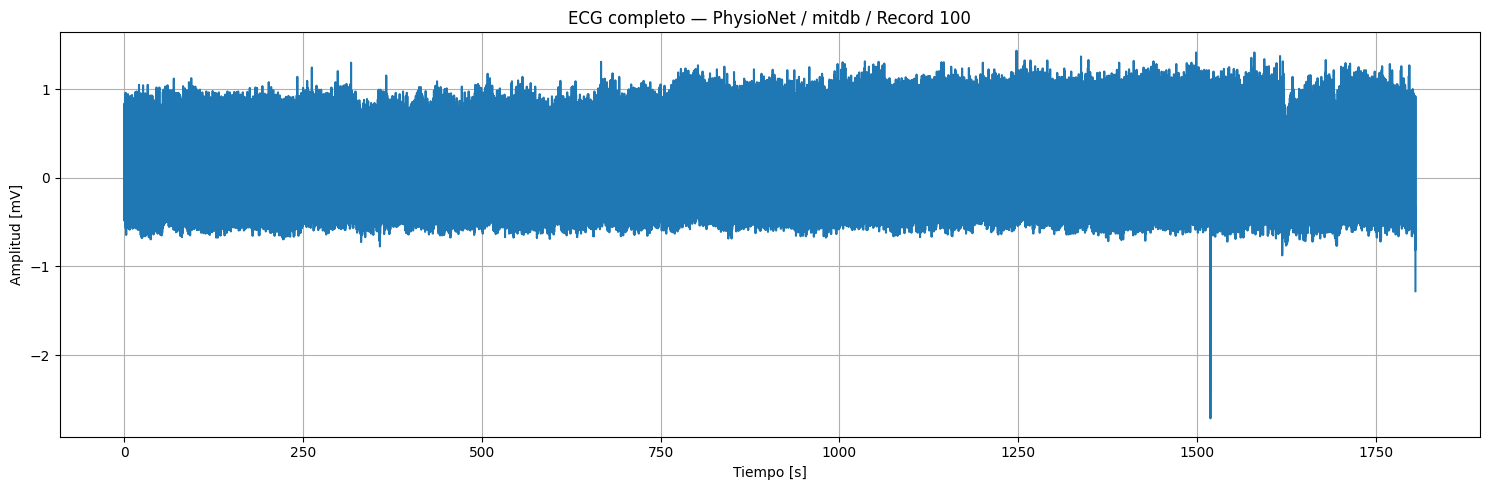

In [10]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. __¿La señal presenta una amplitud constante?__
La amplitud varía a lo largo del registro sin ser constante, se observa que la señal tiene cambios en su nivel, además de algunos picos de mayor amplitud.

2. __¿Se pueden identificar visualmente complejos QRS?__
No, no se pueden identificar los complejos QRS, debido a que el plot representa una señal de ECG de 1807 segundos de duracion, y los valores de la señal en cada instante estan muy juntos como para poder distingir estos complejos QRS.
3. __¿La morfología permanece igual durante todo el registro?__
Probablemente no, ya que se observan secciones de la señal con valores que varian mucho de los demas.
4. __¿Se observa ruido?__
Si se observa ruido.
5. __¿Qué ventajas tiene visualizar una señal durante varios minutos?__
Permite detectar arritmias intermitentes y analizar la variabilidad de la frecuencia cardíaca (HRV), eventos que no aparecen en un registro corto de 10 segundos.
6. __¿Qué limitaciones tiene una gráfica demasiado extensa?__
Se pierde detalle de la señal y ralentiza el sistema por saturacion de datos en pantalla.



# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [11]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


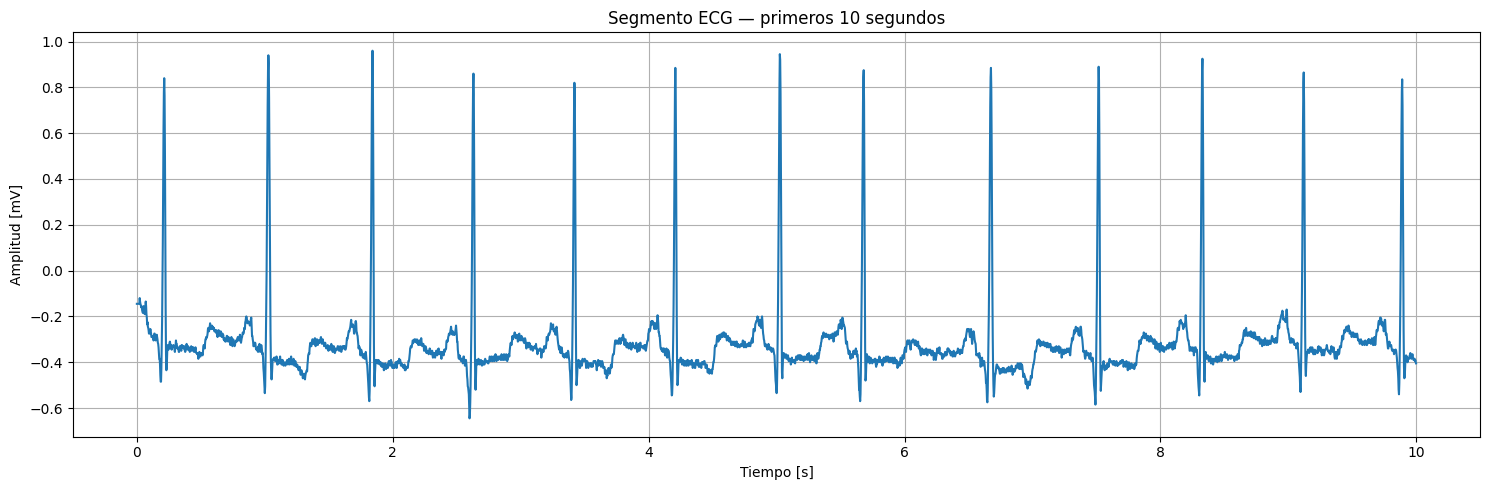

In [12]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


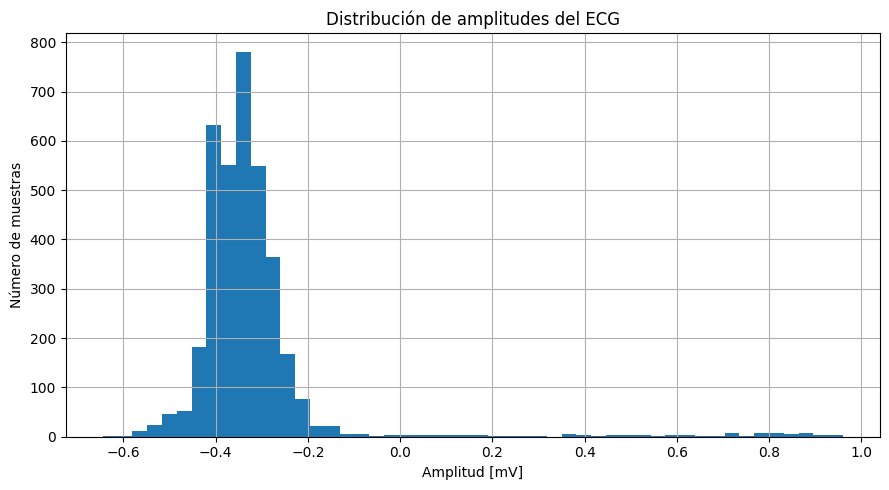

In [13]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. __¿Dónde se concentra la mayor cantidad de muestras?__ Hay mayor concentracion de muestras en amplitudes entre -0.5 mV y -0.3 mV
2. __¿La distribución parece simétrica?__ No, ya que tiene un pico de muestras en amplitudes de aproximadamente -0.4 mV
3. __¿Existen valores extremos?__ Si, existen valores extremos en ~-.0.7 mV y ~0.95 mV
4. __¿Qué podría producir valores de amplitud muy diferentes al valor central?__
5. __¿El histograma conserva información temporal?__ Explique.
No, la informacion temporal se pierde. Este histograma solo muestra la distribucion de muestras en las amplitudes de la señal ECG.


# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


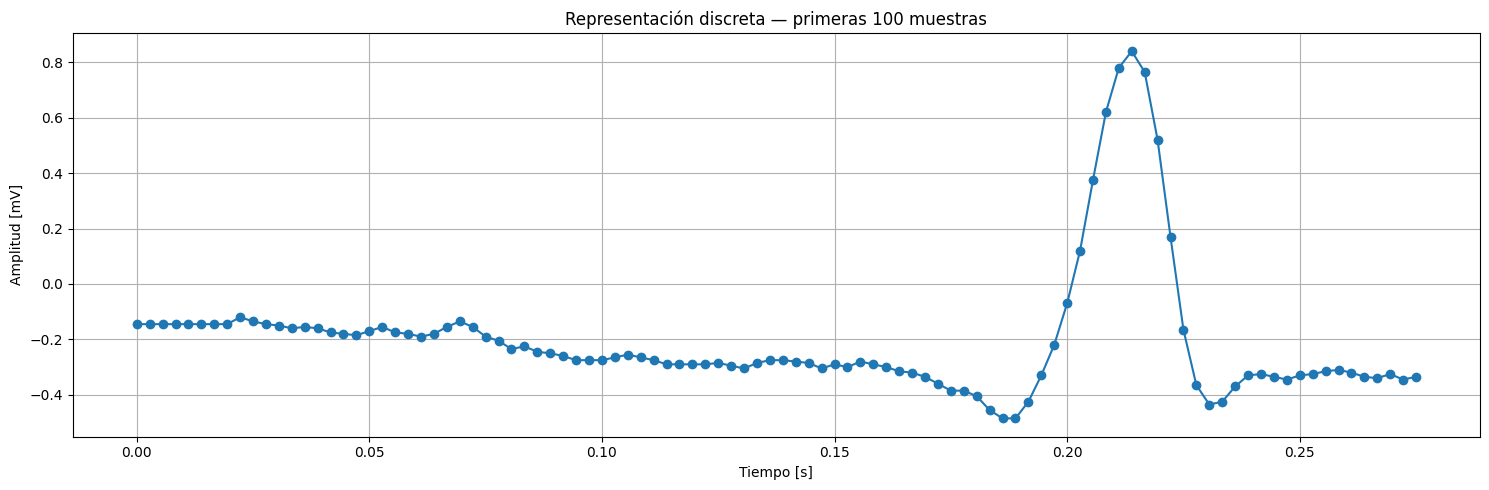

In [14]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. __¿Cuántas muestras existen por segundo?__ El numero de muestras por segundo (fs) es la misma que de la señal ECG en si: fs = 360 Hz
2. __¿Qué ocurre si aumentamos `fs`?__ La señal se vuelve mas corta en el tiempo, las 100 muestras discretas se muestran en un tiempo mas corto.
3. __¿Qué ocurre si disminuimos `fs`?__ Lo opuesto al caso anterior, las 100 muestras discretas se muestran en un tiempo mas largo.
4. __¿Qué representa el eje `n` en una señal discreta?__ Representa a las muestras en un eje discreto, donde n=1 representa a la primera muestra de la señal ECG.
5. __¿Cuál es la relación entre `n`, `fs` y `t`?__ $$t(segundo) = \frac{n(muestras)}{fs(\frac{muestras}{segundo})}$$



# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [15]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:


$$-32768 \leq x \leq 32767$$


para `int16`.


In [16]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [17]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [18]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)



### Preguntas de análisis 5

1. __¿Puede escuchar claramente la señal?__ Si
2. __¿El sonido corresponde a un sonido fisiológico real?__ El ECG registra actividad eléctrica, no sonido. El sonido cardíaco real es mecánico y proviene del cierre de las válvulas. Lo que se oye solo una traducción de esa electricidad a vibraciones de altavoz.
3. __¿Por qué un ECG puede convertirse a WAV?__ Si, porque, tanto un ECG como el audio digital son simplemente una secuencia ordenada de números tomados a intervalos regulares de tiempo.
4. __¿Qué información se conserva al hacer la conversión?__ Al convertir el ECG a WAV se conservan toda la información temporal y de ritmo, y la morfologia.
5. __¿Qué información fisiológica podría perderse al escucharla?__ La magnitud física real. Al centrar y normalizar la señal a enteros de 16 bits para el formato de audio, ya no se puede saber el voltaje real que generó el corazón, solo sus proporciones.
6. __¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?__ La gráfica permite medir con precisión la forma y el voltaje real de cada onda, mientras que el audio sirve para percibir al instante el ritmo y sus irregularidades usando el oído, sin necesidad de mirar una pantalla.



# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [19]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "101"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("=" * 55)
print("Parámetros configurados:")
print("=" * 55)
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

# CARGAR REGISTRO DESDE PHYSIONET

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# INFORMACIÓN DEL REGISTRO

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total1 = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_101_channel_0.wav
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 101
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V1 [mV]

Canal seleccionado: 0
Nombre            : MLII



# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.



#### Se esta tomando el registro __101__


In [20]:
DATABASE = "mitdb"
RECORD = "101"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

# CARGAR REGISTRO DESDE PHYSIONET

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# INFORMACIÓN DEL REGISTRO

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_101_channel_0.wav
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 101
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos


### Grafica 1:

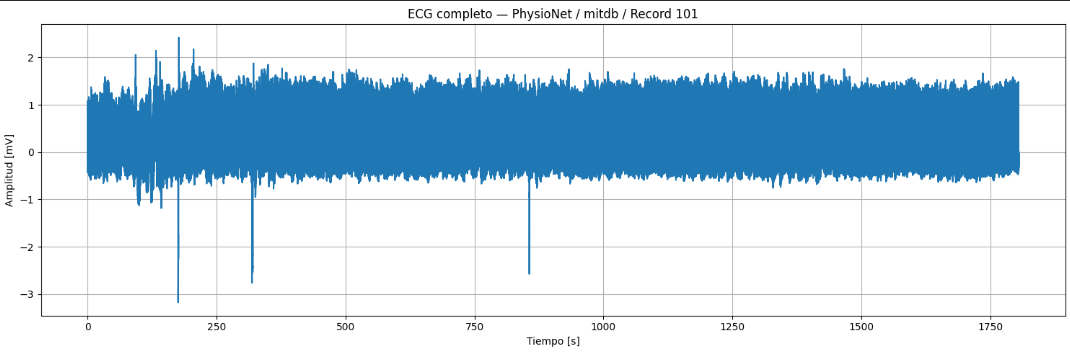

### Grafica 2:

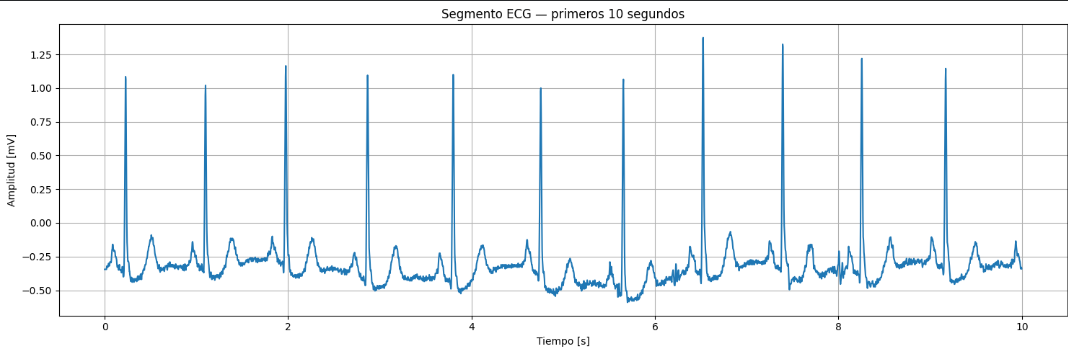

### Grafica 3:

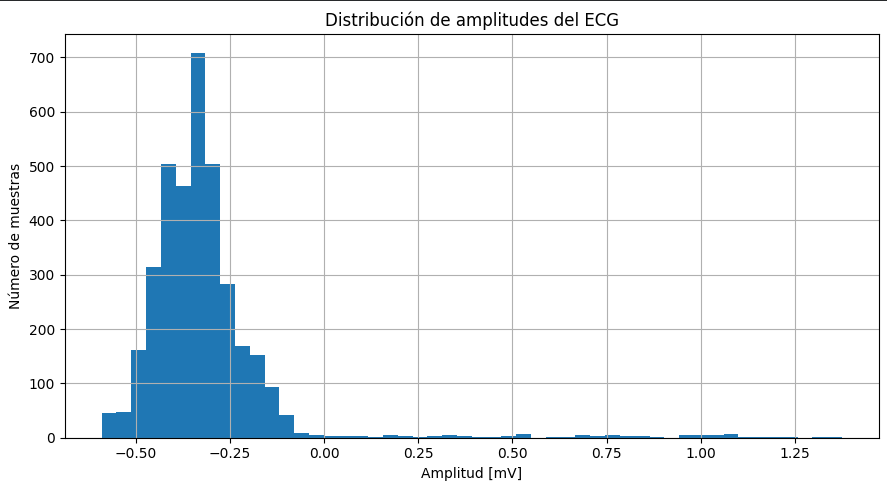

### Grafica 4:

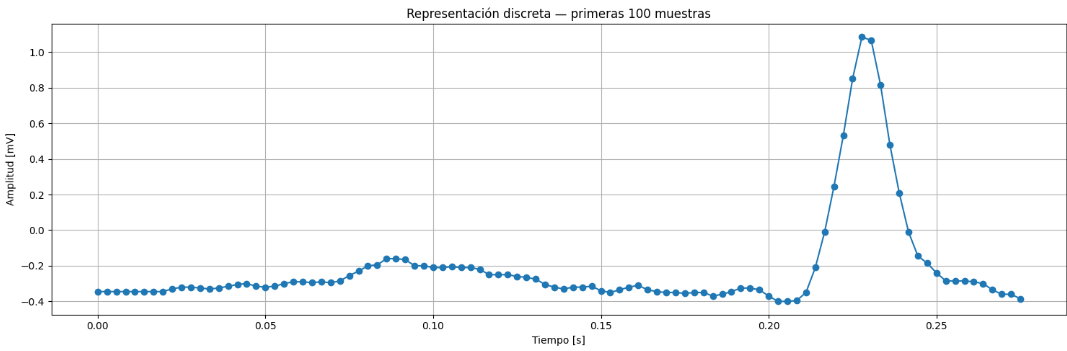



- frecuencia de muestreo: Ambos tienen una frecuencia de muestreo de 360 Hz
- número de canales: Tienen dos canales continuos
- nombres de canales:
  - Registro 100:
    - Canal 0: MLII
    - Canal 1: V5
  - Registro 101:
    - Canal 0: MLII
    - Canal 1: V1
- morfología:
  - Registro 100: Señal limpia, onda P casi plana y onda T pequeña.
  - Registro 101: Más ruidosa (EMG), con ondas P y T muy marcadas.
- amplitud:
  - Registro 100: Picos R muy estables y pocos picos anómalos.
  - Registro 101: Picos R variables con artefactos extremos
- distribución:
  - Registro 100: Histograma angosto centrado en -0.35 mV con cola corta hasta 1 mV
  - Registro 101: Histograma más disperso en la base con cola larga hasta casi 1.4 mV

---

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

Responda:

1. ¿Qué nombre tiene el nuevo canal?
2. ¿Tiene las mismas unidades?
3. ¿La morfología es igual?
4. ¿Qué diferencias observa?



Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 1
Duración      : 10 s
Archivo WAV   : ecg_record_101_channel_1.wav
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 101
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V1 [mV]

Canal seleccionado: 1
Nombre            : V1
Número de muestras: 650000
Canal: V1
Unidad: mV

Primeras 10 muestras:
[-0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.15  -0.145]
Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos


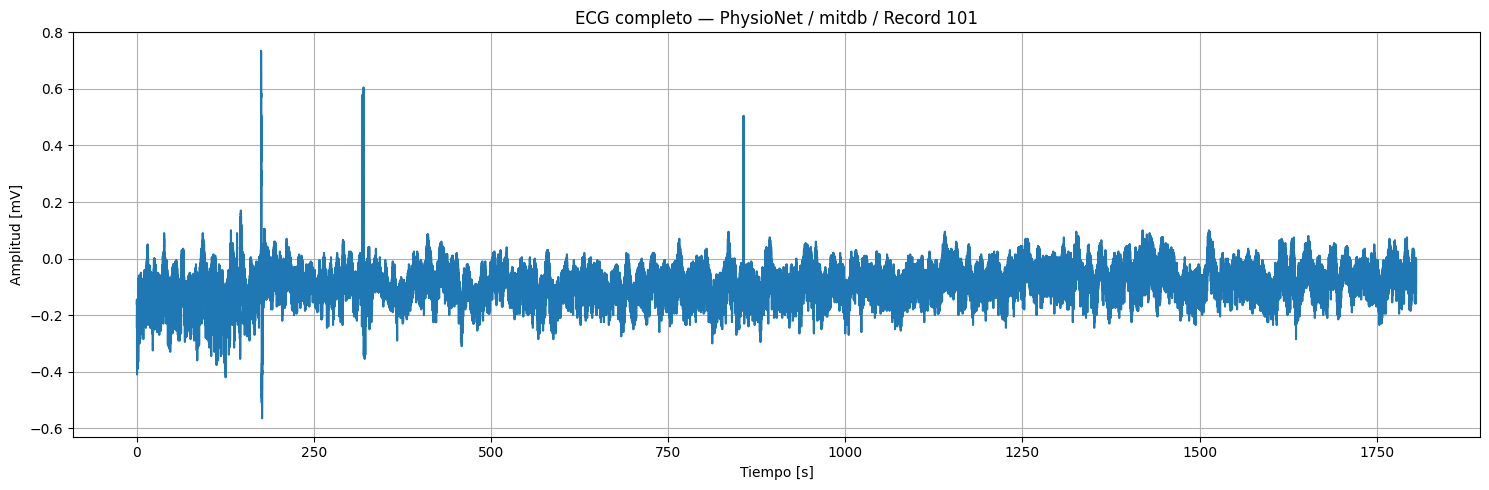

Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


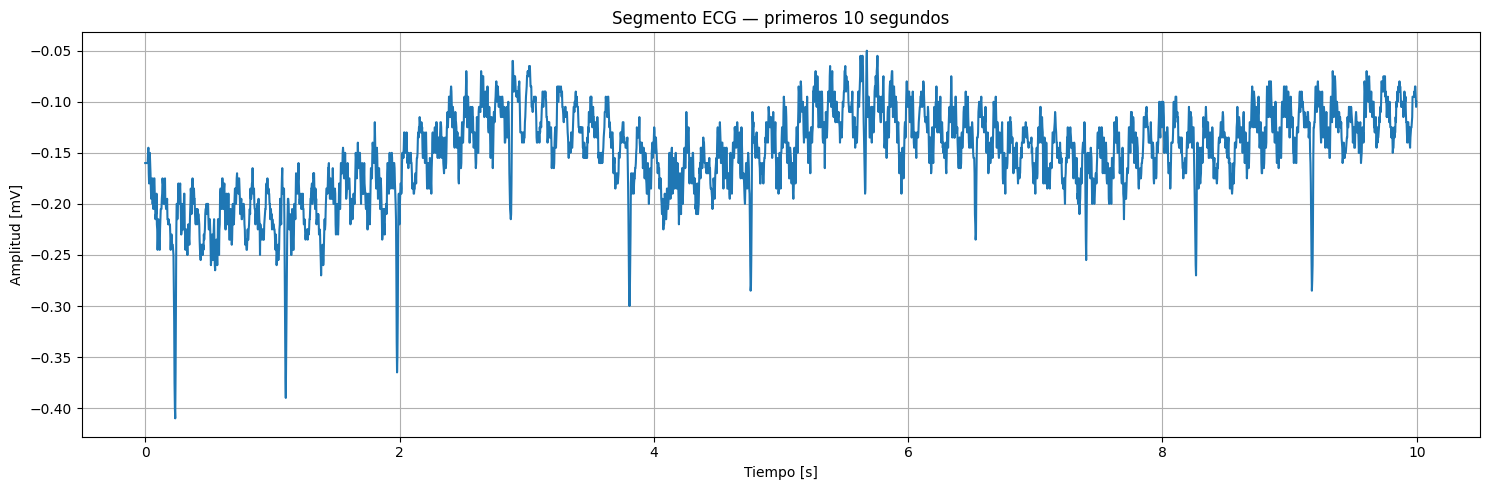

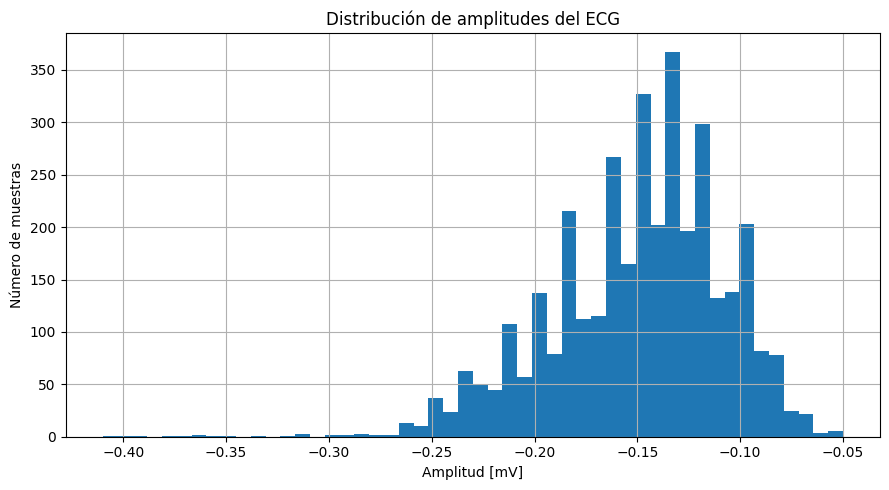

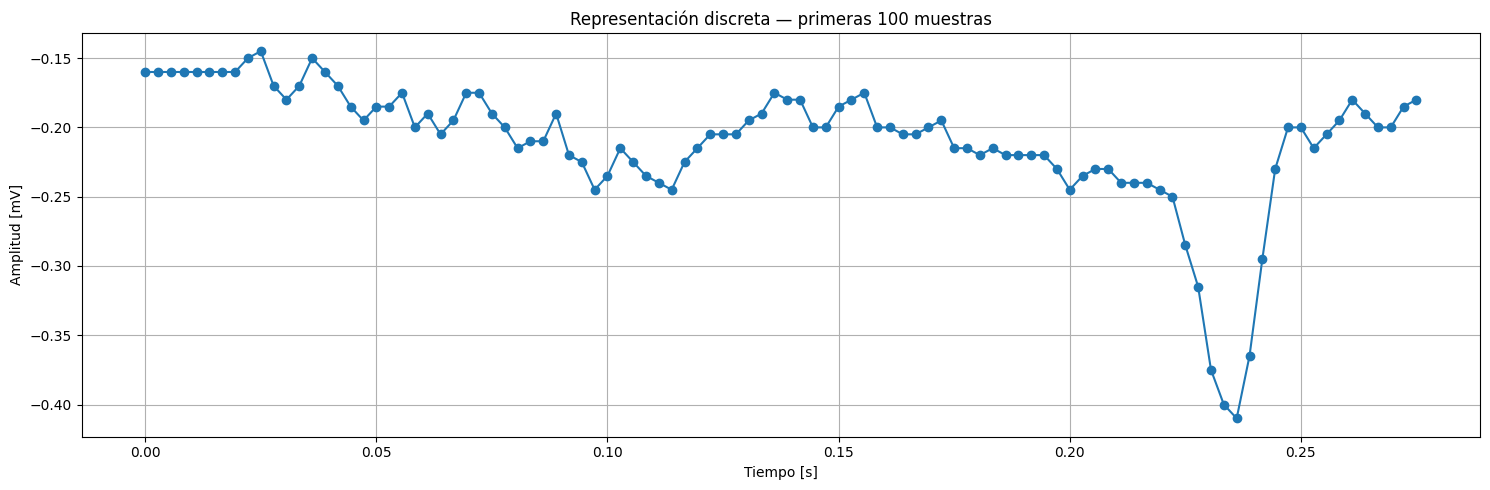

In [21]:
# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "101"

CHANNEL = 1

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()


---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.


### Con duracion de 5 segundos

Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 1
Duración      : 5 s
Archivo WAV   : ecg_record_101_channel_1.wav
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 101
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V1 [mV]

Canal seleccionado: 1
Nombre            : V1
Número de muestras: 650000
Canal: V1
Unidad: mV

Primeras 10 muestras:
[-0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.15  -0.145]
Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos


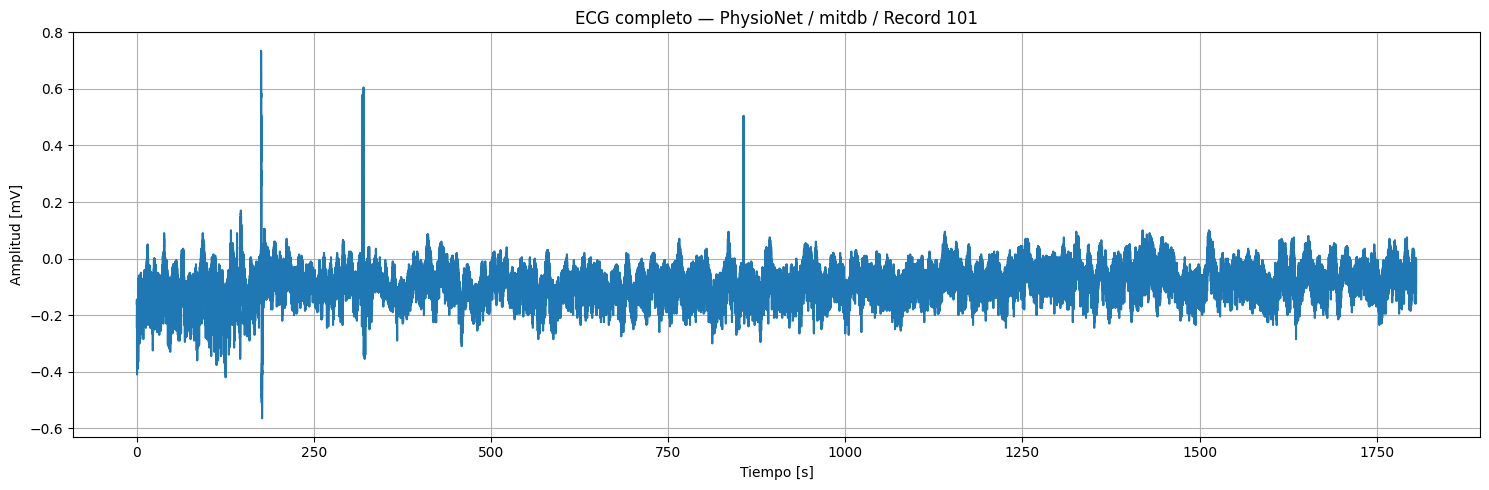

Duración solicitada : 5 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 1800


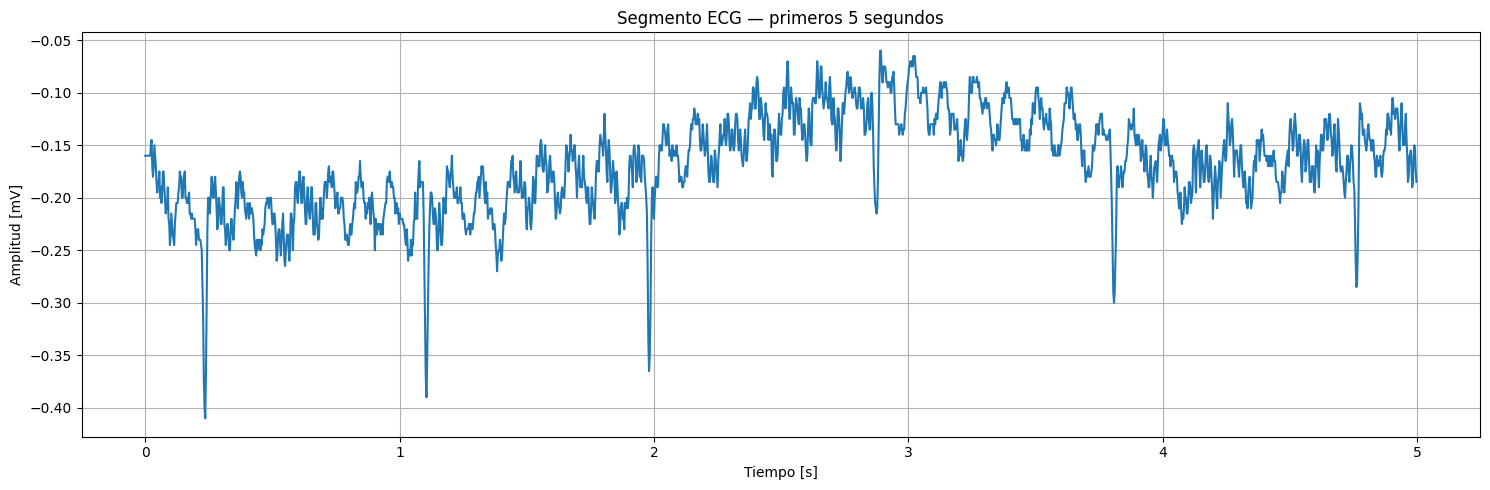

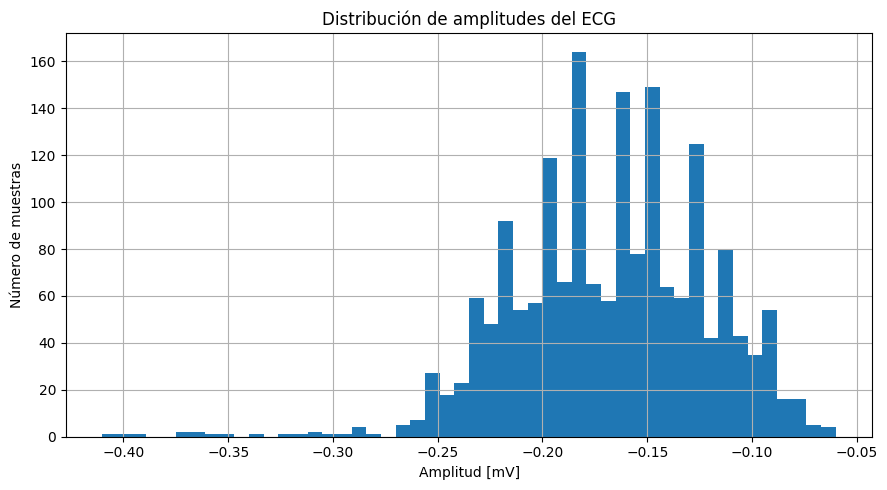

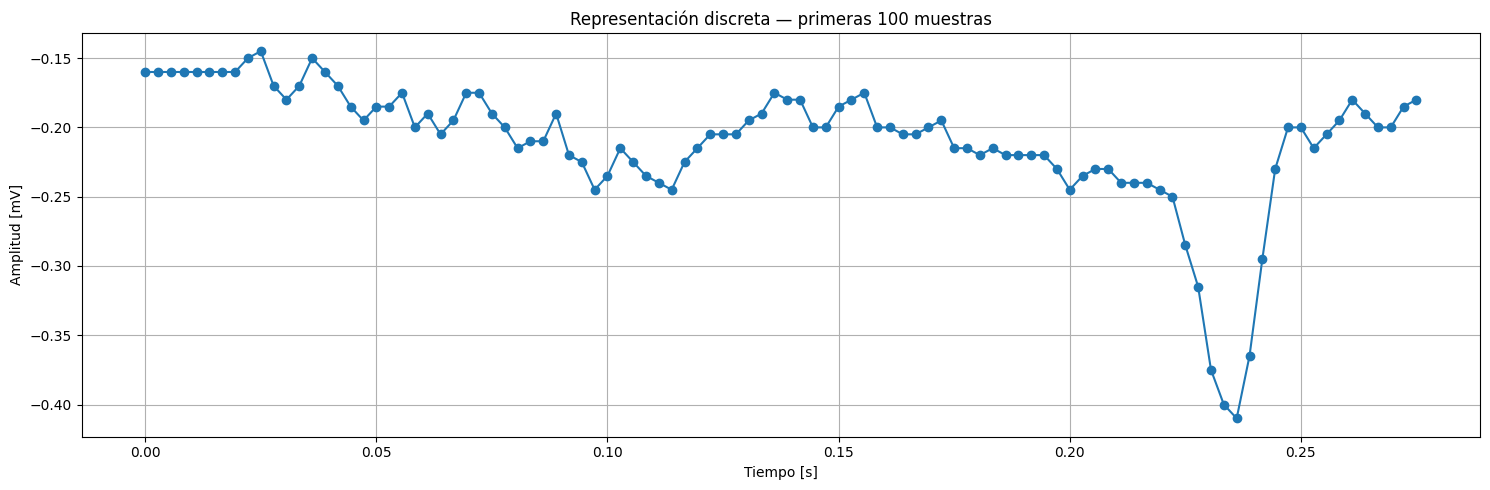

In [22]:
# PARÁMETROS

DATABASE = "mitdb"
RECORD = "101"

CHANNEL = 1

DURATION = 5  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# INFORMACIÓN DEL REGISTRO

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# EXTRAER CANAL

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# EJE TEMPORAL

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# GRÁFICA 1: ECG COMPLETO

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# SELECCIONAR SEGMENTO

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# GRÁFICA 2: SEGMENTO ECG

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# GRÁFICA 3: HISTOGRAMA

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# GRÁFICA 4: MUESTRAS DISCRETAS

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

### Con duracion de 20 segundos

In [23]:
# PARÁMETROS

DATABASE = "mitdb"
RECORD = "101"

CHANNEL = 1

DURATION = 20  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# INFORMACIÓN DEL REGISTRO

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# EXTRAER CANAL

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# EJE TEMPORAL

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# GRÁFICA 1: ECG COMPLETO

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# SELECCIONAR SEGMENTO

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# GRÁFICA 2: SEGMENTO ECG

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# GRÁFICA 3: HISTOGRAMA

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# GRÁFICA 4: MUESTRAS DISCRETAS

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 1
Duración      : 20 s
Archivo WAV   : ecg_record_101_channel_1.wav


NetFileError: 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/

En una respuesta muy corta (5 segundos), hay muy pocos latidos (4 a 6) para evaluar el ritmo con certeza o detectar arritmias, y la muestra estadística es insuficiente.

En una respuesta demasiado larga (20 segundos), La gráfica se comprime horizontalmente, lo que oculta los detalles finos de la morfología (ondas P, T y segmento ST) y hace que los artefactos por respiración alteren la escala visual.


## Ejercicio 4 — Frecuencia de muestreo

Suponga que:


$$f_s = 360 Hz$$

### a) Calcule el periodo de muestreo:

$$T_s = \frac{1}{f_s}$$




In [ ]:
Ts = 1/fs
print(f"La frecuencia de muestreo es: {fs} Hz")
print(f"El periodo de muestro es: {Ts} segundos")

### b) ¿Cuántas muestras existen en 5 segundos?



In [ ]:
Tiempo = 5
N = Tiempo*fs
print(f"En 5 segundos existen {N} muestras")

### c) ¿Cuántas muestras existen en 10 segundos?



In [ ]:
Tiempo = 10
N = Tiempo*fs
print(f"En 10 segundos existen {N} muestras")

### d) Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.



Si la frecuencia de muestreo se redujera drásticamente, la señal sufriría una severa degradación tanto técnica como morfológica. Al incumplirse el teorema de muestreo de Nyquist-Shannon frente a las componentes rápidas del ECG, aparecería el fenómeno de aliasing, solapando y distorsionando las frecuencias reales de la onda.

En la práctica, esto provocaría que eventos extremadamente breves como el complejo QRS queden representados por un número insuficiente de muestras, lo que causaría la atenuación artificial de los picos R, al no coincidir el muestreo exactamente con su cúspide, y la deformación completa de ondas críticas como la P, la S y el segmento ST. Además, la pérdida de resolución temporal introduciría errores significativos en el cálculo de los intervalos entre latidos (R-R), invalidando los análisis de variabilidad cardíaca y la detección precisa de arritmias.

Finalmente, en el archivo de audio resultante, la reducción de ancho de banda eliminaría los transitorios agudos, transformando los pulsos nítidos de los latidos en un sonido apagado, sordo y con evidente pérdida de definición.

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.

In [ ]:
# ESTADÍSTICAS BÁSICAS

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")



# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?

hysioNet es un repositorio y recurso de acceso abierto que proporciona de manera gratuita grandes colecciones de registros fisiológicos complejos —como electrocardiogramas (ECG), señales de presión arterial, etc.

### 2.
¿Qué diferencia existe entre `DATABASE` y `RECORD`?

La base de datos es la carpeta o biblioteca completa donde se agrupa decenas de grabaciones recopiladas bajo un mismo estudio.

El registro es el archivo que contiene las señales y canales de un paciente especifico

### 3.
¿Qué representa `fs`?

Numero de muestras por segundo.

### 4.
¿Qué representa `CHANNEL`?

Representa el canal donde se toman las señales, en el caso de los registros en mitdb, los canales MLII, V1 y V5 representan la posicion en la que se coloca la "camara" para tomar las señales ECG

### 5.
¿Qué representa `record.p_signal`?

Representan un arreglo con todas las muestras contenidas en la señal ECG dentro de un determinado canal, sus unidades, en este caso, son mV.

### 6.
¿Por qué necesitamos construir un eje temporal?

Se tiene que crear un eje temporal del mismo tamaño que record.p.signal para asignar una muestra a un instante en el tiempo, si no se hace esto, la señal no se graficara correctamente.

### 7.
¿Qué diferencia existe entre una señal continua y una señal discreta?

Una señal continua existe como una funcion continua, en cualquier instante de tiempo, mientras que una señal discreta solo tiene valores definidos dentro de instantes especificos, definidos por una frecuencia de muestreo.

### 8.
¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?

Porque al crear el WAV se pierde el voltaje real (milivoltios) debido a la normalización, se elimina la componente continua (DC),borrando desniveles clave como el segmento ST, y los altavoces no reproducen las frecuencias subacústicas (menores a 20 Hz) donde reside la mayor parte de la información médica del ECG.

### 9.
¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?

Las señales reales contienen la complejidad fisiológica auténtica y el ruido del mundo real. Esto permite validar algoritmos y filtros bajo condiciones clínicas exigentes que los modelos sintéticos difícilmente logran replicar con fidelidad.

### 10.
¿Qué dificultades encontró durante el laboratorio?

Entender los comandos en python utilizados para el desarrollo del laboratorio.


# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.


In [ ]:
# PARÁMETROS DEL LABORATORIO

DATABASE = "mitdb"
RECORD = "102"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# INFORMACIÓN DEL REGISTRO

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO:")


print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")
print("=" * 55)

# EXTRAER CANAL

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])
print("=" * 55)

# EJE TEMPORAL

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()
print("=" * 55)

# SELECCIONAR SEGMENTO

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")
print("=" * 55)

# GRÁFICA 2: SEGMENTO ECG

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()
print("=" * 55)

# GRÁFICA 3: HISTOGRAMA

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()
print("=" * 55)

# GRÁFICA 4: MUESTRAS DISCRETAS

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ESTADÍSTICAS BÁSICAS

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")
print("=" * 55)

# PREPARAR ECG PARA WAV

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")
print("=" * 55)

# GUARDAR WAV

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)
print("=" * 55)

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)


### Interpretación de los Resultados:\
- ECG completo
  - La señal se mantiene bastante pareja y estable durante casi todo el tiempo.

  - Hay un momento breve (entre el segundo 120 y 180) donde la señal se vuelve más pequeña de golpe, probablemente porque el paciente se movió o el electrodo se aflojó un poco.

 - Se ven unas pocas líneas largas hacia abajo, que son simples tirones o ruidos por movimiento.
- Gráfica de los 10 segundos:
  - Forma del latido: Cada latido tiene una forma especial: primero da un pico muy fino y rápido hacia arriba (parecido a la marca que deja un marcapasos), luego hace una pequeña curva ancha y enseguida cae con fuerza hacia abajo.
  - Ritmo: Los latidos caen casi con la precisión de un reloj (unos 13 latidos en 10 segundos, es decir, unos 78 latidos por minuto), lo que es muy típico cuando un marcapasos marca el paso del corazón.
- Gráfica del histograma (distribución de amplitudes):
  - La barra más alta muestra que la señal pasa la mayor parte del tiempo quieta en reposo (alrededor de $-0.25\text{ mV}$).
  - A diferencia de otros registros normales, aquí aparece una "segunda montañita" pequeña cerca de $+0.15\text{ mV}$. Esto ocurre porque la parte de arriba del latido es ancha y la señal se queda un ratito en valores positivos antes de bajar.
- Gráfica de las primeras 100 muestras:
  - Muestra cómo la computadora toma una foto de la señal cada fracción de segundo.
  - Durante los primeros instantes la línea está en reposo casi plano, y justo al final de la gráfica (segundo 0.27) se ve cómo sube de golpe para empezar el primer latido.

### Conclusiones

- Los datos se procesaron bien: La señal se leyó sin errores, no se cortaron los picos y los cálculos matemáticos funcionaron como debían.

- Es un latido muy diferente a los anteriores (100 y 101): Este paciente tiene un marcapasos y usamos otro canal (V5), por lo que el latido se ve con una espiga aguda y una forma doble que no aparecía en los otros pacientes.

- El audio sonará distinto: Debido a que el latido sube tan rápido y en punta, al escucharlo en el archivo .wav se oirá como un golpe o clic más seco y marcado que en un latido común


# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
